# SOLUTION: Monthly quantile climatology calculations

Extend the previous example to include the 10th to 90th precentile range of the monthly climatology

In [1]:
from earthkit import data as ekd
from earthkit import plots as ekp
from earthkit import transforms as ekt
from earthkit.transforms._tools import earthkit_remote_test_data_file

Get some demonstration ERA5 data, this could be any url or path to an ERA5 grib or netCDF file.

In [2]:
remote_era5_file = earthkit_remote_test_data_file("ERA5-Reading-2m-temperature-1940-2025.nc")
era5_xr = ekd.from_source("url", remote_era5_file).to_xarray()
era5_xr

<xarray.Dataset> Size: 9MB
Dimensions:     (valid_time: 753888)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 3MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Calculate the climatologies

The climatology module offers a range of methods for calculating climatological statistics.
First we will use the basic methods to calculate climatological mean and standard-deviation
representative of the climatology period 1991-2020.

The `climatology_range` must provide the start and end date for the climatology period. 
It can be provided as date strings which are recognised by `xarray`,
for example `"YYYY"`, `"YYYY-MM"` and `"YYYY-MM-DD"`, or as a date objects such as
`datetime` objects or `numpy.datetime64` objects.

If the climatology range is not provided, then the whole time-period in the input data is used.

In [3]:
climatology_mean = ekt.climatology.mean(era5_xr, climatology_range=("1991", "2020"))
climatology_std = ekt.climatology.std(era5_xr, climatology_range=("1991", "2020"))
print(
    f"Climatology mean = {float(climatology_mean.t2m)}\nClimatology standard deviation = {float(climatology_std.t2m)}"
)
climatology_mean

Climatology mean = 283.6854248046875
Climatology standard deviation = 5.9290385246276855


<xarray.Dataset> Size: 20B
Dimensions:    ()
Coordinates:
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    t2m        float32 4B 283.7
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

### Monthly and daily climatologies

It is possible to calculate monthly and daily climatological statistics using the methods
described in the [API reference guide](https://earthkit-transforms.readthedocs.io/en/latest/autodocs/earthkit.transforms.climatology.html)

The monthly/daily climatologies provide a value of the requested statistic for each
calendar-month/day-of-year over the `climatology_range` period.

In the examples below, we calculate the monthly and daily mean for our 2m temperature data for the
`climatology_range` 1990 to 2020.
In the returned objects the valid_time dimension has been replaced with a
`month`/`dayofyear` dimension.

In [11]:
climatology_monthly_mean = ekt.climatology.monthly_mean(era5_xr, climatology_range=("1991", "2020"))
climatology_monthly_mean

<xarray.Dataset> Size: 160B
Dimensions:    (month: 12)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    latitude   float64 8B 51.5
    longitude  float64 8B -1.0
Data variables:
    t2m        (month) float32 48B 278.0 278.2 280.0 282.3 ... 284.2 280.8 278.4
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [ ]:
climatology_daily_mean = ekt.climatology.daily_mean(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_min = ekt.climatology.daily_min(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_max = ekt.climatology.daily_max(era5_xr, climatology_range=("1991", "2020"))
climatology_daily_mean

### Monthly quantiles

The API for climatology quantiles is slightly different, it requires an additional argument `q` which is a
list of the quantiles to return.
Additionally, the returned object has `quantiles` dimension which is for each of the quantiles returned.

In [6]:
climatology_monthly_quantiles = ekt.climatology.quantiles(
    era5_xr, [0.1, 0.5, 0.9], frequency="month", climatology_range=("1991", "2020")
)
climatology_monthly_quantiles

<xarray.Dataset> Size: 408B
Dimensions:   (quantile: 3, month: 12)
Coordinates:
  * quantile  (quantile) float64 24B 0.1 0.5 0.9
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    t2m       (quantile, month) float64 288B dask.array<chunksize=(1, 1), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Plot the output

First we plot the climatology data using an earthkit-plots `Climatology` figure.

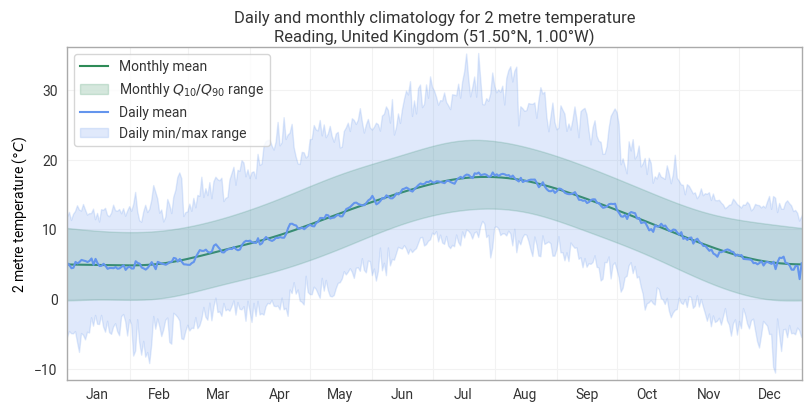

In [ ]:
chart = ekp.Climatology(wrap_time=True)

chart.fix_y_units("celsius")

# Monthly median + q10/q90 envelope
chart.line(climatology_monthly_quantiles.sel(quantile=0.5), label="Monthly median", color="seagreen", drawstyle="spline")
chart.fill_between(
    climatology_monthly_quantiles.sel(quantile=0.1),
    climatology_monthly_quantiles.sel(quantile=0.9),
    label="Monthly $Q_{10} / Q_{90}$ range",
    color="seagreen",
    drawstyle="spline",
)

# Daily mean + min/max envelope
chart.line(
    climatology_daily_mean,
    label="Daily mean",
    color="cornflowerblue",
)
chart.fill_between(
    climatology_daily_min,
    climatology_daily_max,
    label="Daily min/max range",
    color="cornflowerblue",
)

chart.title(
    "Daily and monthly climatology for {variable_name}\n{location:%c}, {location:%C} ({latitude:%Lt}, {longitude:%Ln})"
)
chart.xticks(frequency="M", period=True)
chart.ylabel()
chart.legend()
chart.show()